In [1]:
!pip install qiskit qiskit-aer matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 92.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.5 MB/s eta 0:00:00


In [2]:
from qiskit import QuantumCircuit
# Create a 2-qubit circuit
qc = QuantumCircuit(2)
# Put control qubit into |1>
qc.x(0)
# Apply CNOT
qc.cx(0, 1)
# Display circuit
print("CNOT Circuit:")
print(qc.draw())
# Get statevector
from qiskit.quantum_info import Statevector

state = Statevector.from_instruction(qc)

print("\nFinal Statevector:")
print(state)

CNOT Circuit:
     ┌───┐     
q_0: ┤ X ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘

Final Statevector:
Statevector([0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
            dims=(2, 2))


GHZ Circuit:
     ┌───┐          ┌─┐      
q_0: ┤ H ├──■───────┤M├──────
     └───┘┌─┴─┐     └╥┘┌─┐   
q_1: ─────┤ X ├──■───╫─┤M├───
          └───┘┌─┴─┐ ║ └╥┘┌─┐
q_2: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     0  1  2 

Measurement Counts:
{'000': 506, '111': 518}


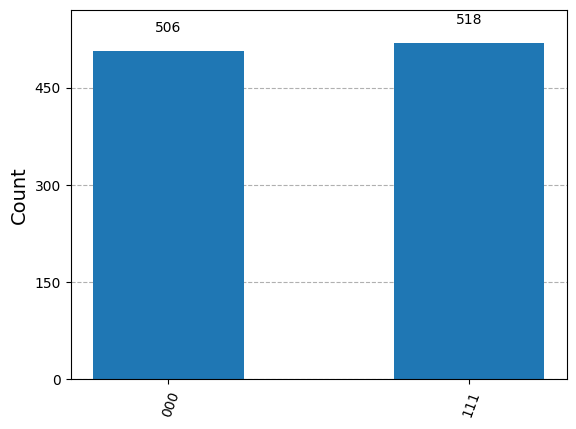

In [3]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
# Create 3 qubits and 3 classical bits
ghz = QuantumCircuit(3, 3)
# Put first qubit into superposition
ghz.h(0)
# Entangle qubit 0 with qubit 1
ghz.cx(0, 1)
# Entangle qubit 1 with qubit 2
ghz.cx(1, 2)
# Measure all qubits
ghz.measure([0, 1, 2], [0, 1, 2])
print("GHZ Circuit:")
print(ghz.draw())
# Simulator
simulator = AerSimulator()
# Run circuit
result = simulator.run(ghz, shots=1024).result()
# Get counts
counts = result.get_counts()
print("\nMeasurement Counts:")
print(counts)
# Histogram
fig, ax = plt.subplots()
plot_histogram(counts, ax=ax)
plt.show()

In [4]:
from qiskit import QuantumCircuit

# 5 qubits:
# q0 = A
# q1 = B
# q2 = Cin
# q3 = Sum
# q4 = Carry

adder = QuantumCircuit(5)

# Example input:
# A = 1
# B = 1
# Cin = 1

adder.x(0)
adder.x(1)
adder.x(2)

# --------------------------------
# SUM = A XOR B XOR Cin
# --------------------------------

adder.cx(0, 3)
adder.cx(1, 3)
adder.cx(2, 3)

# --------------------------------
# CARRY = AB XOR ACin XOR BCin
# --------------------------------

adder.ccx(0, 1, 4)
adder.ccx(0, 2, 4)
adder.ccx(1, 2, 4)

print("Full Adder Circuit:")
print(adder.draw())

# Statevector
from qiskit.quantum_info import Statevector

state = Statevector.from_instruction(adder)

print("\nFinal Statevector:")
print(state)

Full Adder Circuit:
     ┌───┐                              
q_0: ┤ X ├──■──────────────■────■───────
     ├───┤  │              │    │       
q_1: ┤ X ├──┼────■─────────■────┼────■──
     ├───┤  │    │         │    │    │  
q_2: ┤ X ├──┼────┼────■────┼────■────■──
     └───┘┌─┴─┐┌─┴─┐┌─┴─┐  │    │    │  
q_3: ─────┤ X ├┤ X ├┤ X ├──┼────┼────┼──
          └───┘└───┘└───┘┌─┴─┐┌─┴─┐┌─┴─┐
q_4: ────────────────────┤ X ├┤ X ├┤ X ├
                         └───┘└───┘└───┘

Final Statevector:
Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
            dims=(2, 2, 2, 2, 2))


In [6]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# Create 2-qubit circuit
entangled = QuantumCircuit(2)

# Create arbitrary superposition
theta = 3.14159 / 3

entangled.ry(theta, 0)

# Entangle the qubits
entangled.cx(0, 1)

print("Arbitrary Entangled State Circuit:")
print(entangled.draw())

# Get statevector
state = Statevector.from_instruction(entangled)

print("\nStatevector:")
print(state)

# Display probabilities
print("\nProbabilities:")
print(state.probabilities_dict())

Arbitrary Entangled State Circuit:
     ┌────────────┐     
q_0: ┤ Ry(1.0472) ├──■──
     └────────────┘┌─┴─┐
q_1: ──────────────┤ X ├
                   └───┘

Statevector:
Statevector([0.86602562+0.j, 0.        +0.j, 0.        +0.j,
             0.49999962+0.j],
            dims=(2, 2))

Probabilities:
{np.str_('00'): np.float64(0.7500003830125976), np.str_('11'): np.float64(0.2499996169874024)}
